In [258]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import boxcox
from scipy.stats.mstats import normaltest
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

In [259]:
df = pd.read_csv(r"/kaggle/input/diamonds/diamonds.csv")
df.head(5) #This is a dataset of diamonds with given features and the goal is to predict their prices depending on their features

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


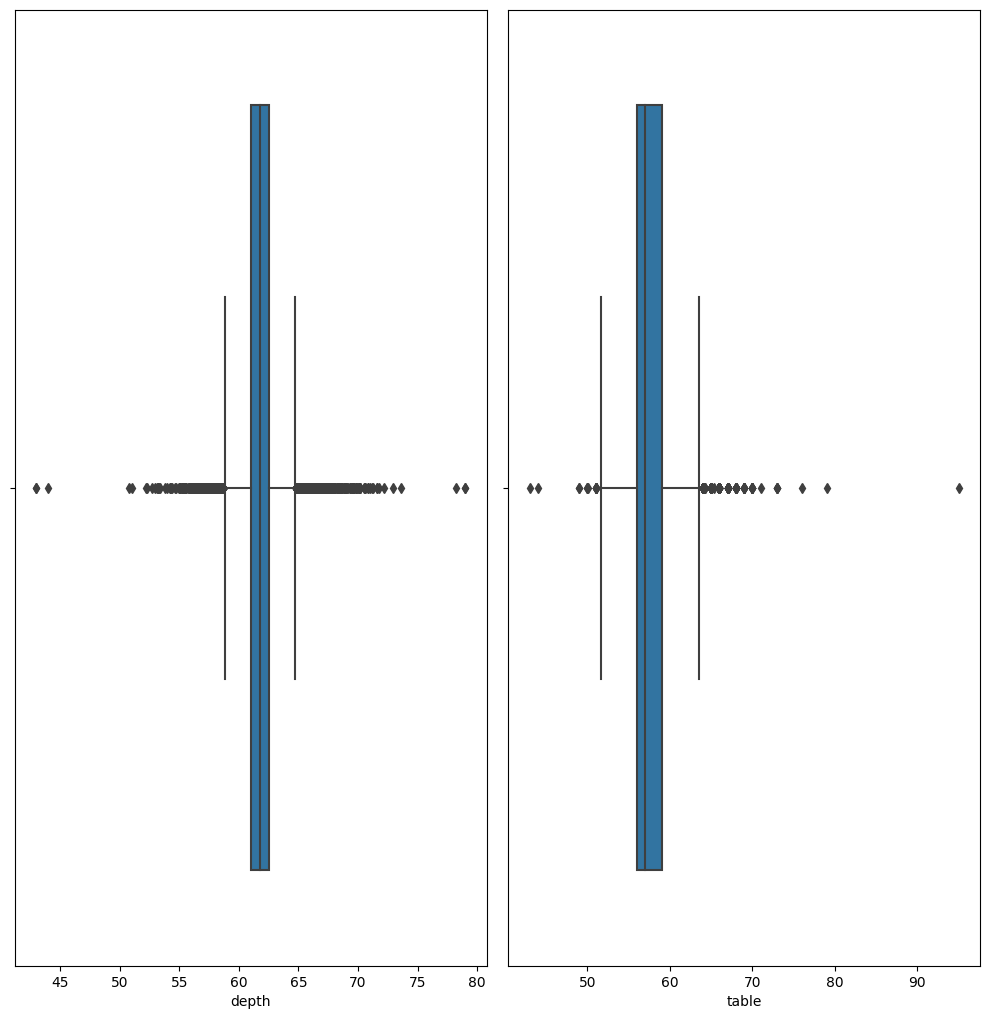

In [260]:
#detecting outliers
plt.figure(figsize=(10, 20))
plt.subplot(2,2,1)
sns.boxplot(x = df['depth'])
plt.subplot(2,2,2)
sns.boxplot(x = df['table'])
plt.tight_layout()
plt.show()

In [261]:
z_scores = stats.zscore(df[['depth','table']]) #detecting outliers
outliers_z = df[(np.abs(z_scores) > 3)]  # Threshold at 3 
df = df.drop(outliers_z.index) #cleaning them

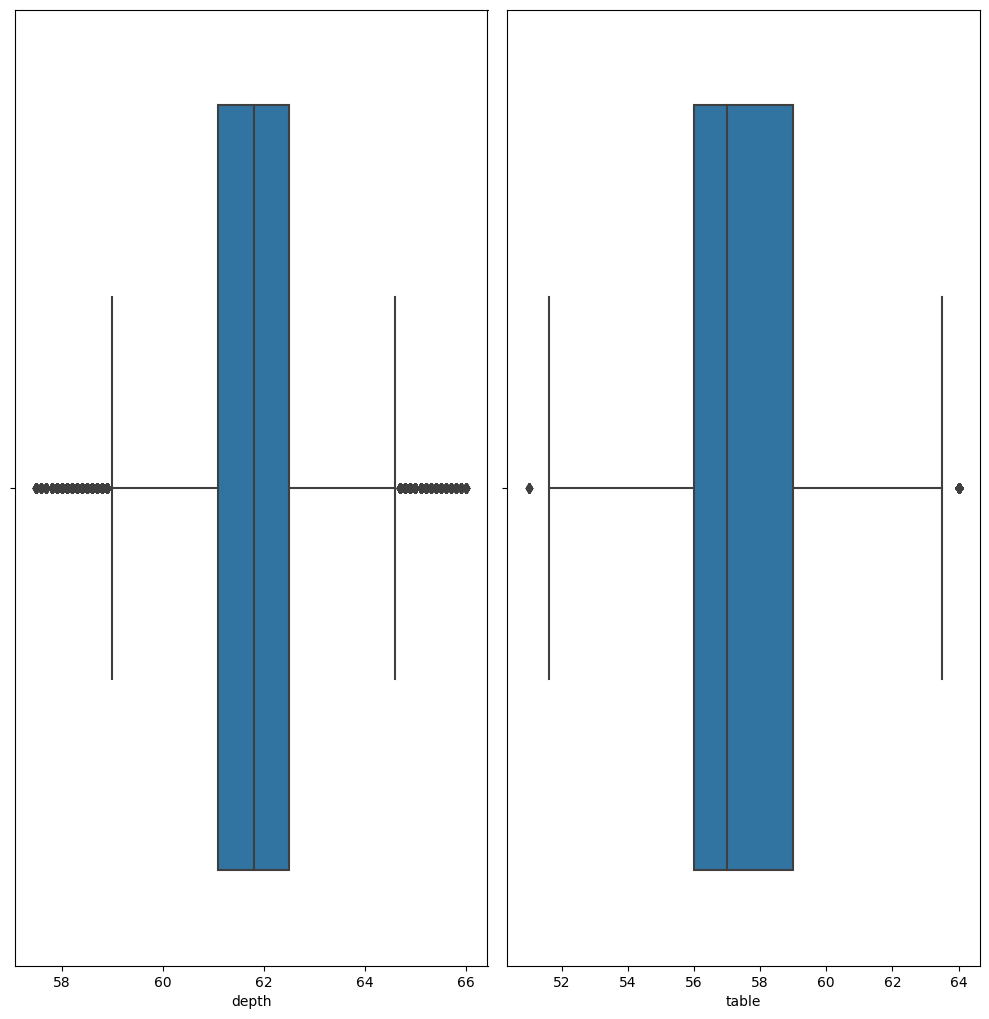

In [262]:
#After cleaning
plt.figure(figsize=(10, 20))
plt.subplot(2,2,1)
sns.boxplot(x = df['depth'])
plt.subplot(2,2,2)
sns.boxplot(x = df['table'])
plt.tight_layout()
plt.show() #Good enough

In [263]:
df.isnull().sum().sum() #Checking for missing values

0

In [264]:
#Seperating features and target
y_df = df[["price"]].copy()
x_df = df.drop("price", axis=1)
y_df

,price
0,326
1,326
3,334
4,335
5,336
...,...
53935,2757
53936,2757
53937,2757
53938,2757


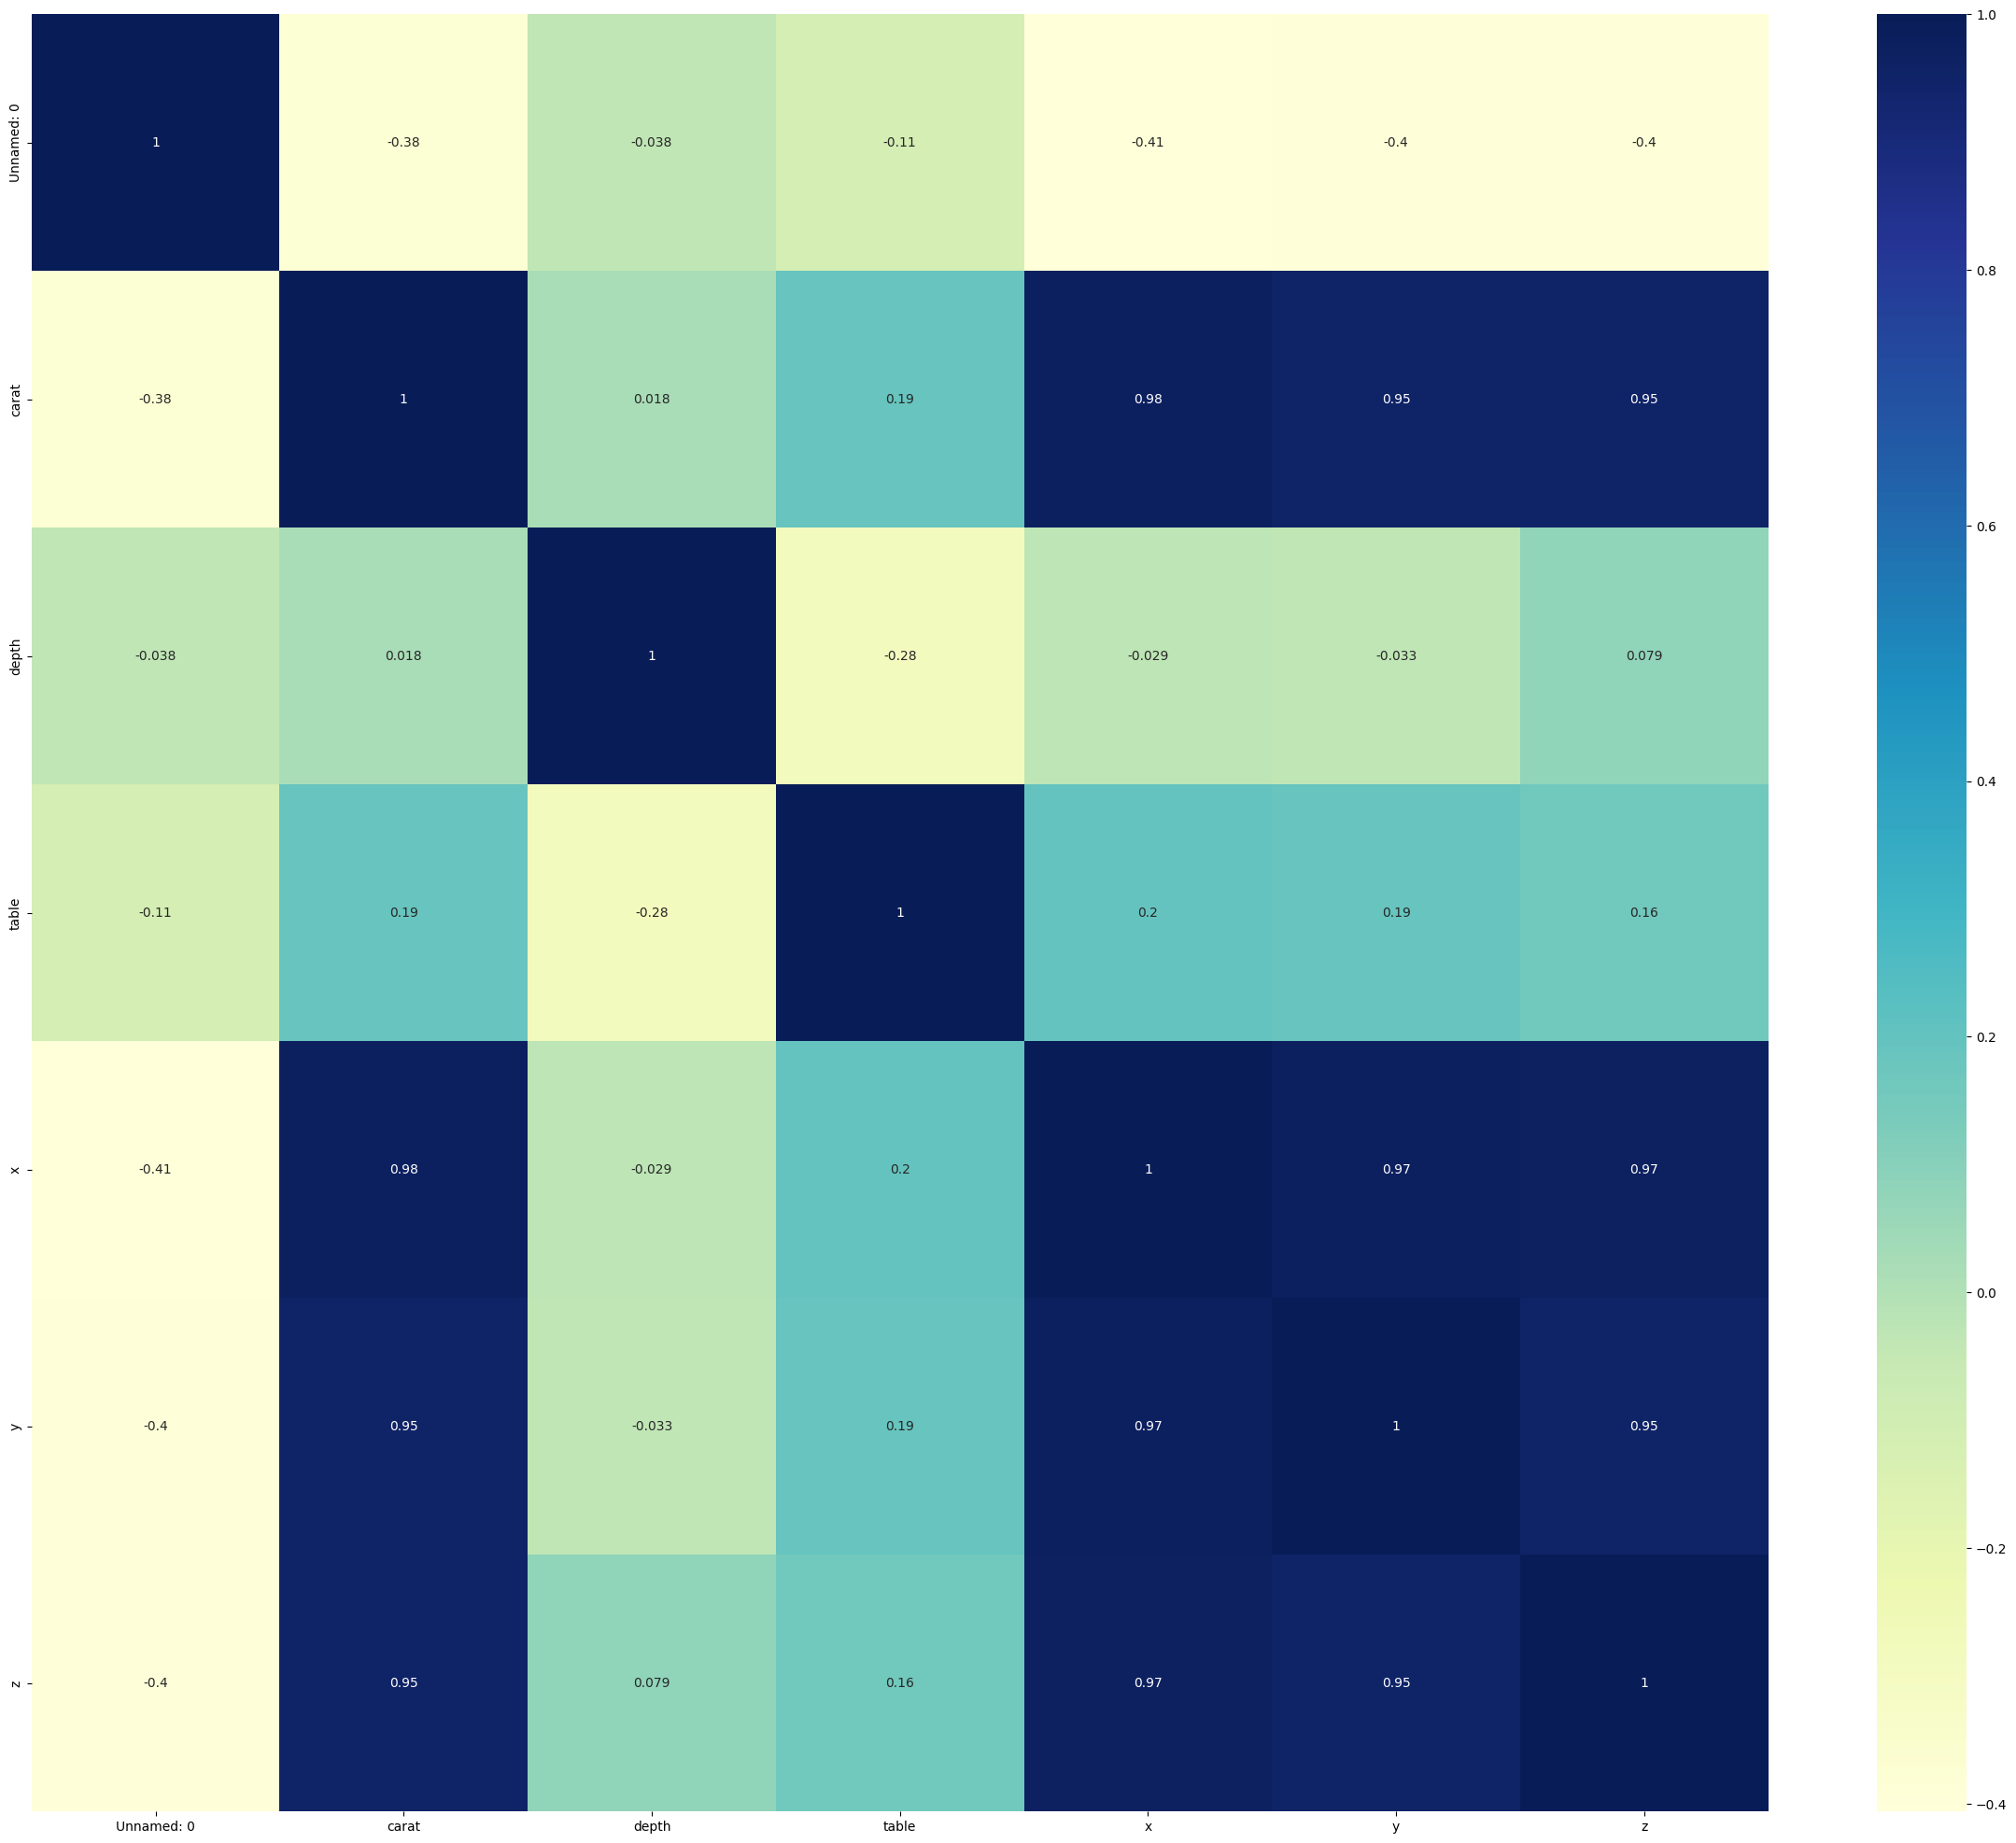

In [265]:
num_data = x_df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize = (30, 25)) 
sns.heatmap(num_data.corr(), annot = True, cmap="YlGnBu")
plt.show() #carat,x,y,z all depend on each other

In [266]:
#keeping only carat
x_df = x_df.drop(columns=['x','y','z'])
x_df

,Unnamed: 0,carat,cut,color,clarity,depth,table
0,1,0.23,Ideal,E,SI2,61.5,55.0
1,2,0.21,Premium,E,SI1,59.8,61.0
3,4,0.29,Premium,I,VS2,62.4,58.0
4,5,0.31,Good,J,SI2,63.3,58.0
5,6,0.24,Very Good,J,VVS2,62.8,57.0
...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0
53936,53937,0.72,Good,D,SI1,63.1,55.0
53937,53938,0.70,Very Good,D,SI1,62.8,60.0
53938,53939,0.86,Premium,H,SI2,61.0,58.0


In [267]:
#Ordinal Encoding
x_df['cut'].unique()
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
encoder = OrdinalEncoder(categories=[cut_order])
x_df['cut_encoded'] = encoder.fit_transform(x_df[['cut']])
x_df = x_df.drop(columns=['cut'])
x_df

,Unnamed: 0,carat,color,clarity,depth,table,cut_encoded
0,1,0.23,E,SI2,61.5,55.0,4.0
1,2,0.21,E,SI1,59.8,61.0,3.0
3,4,0.29,I,VS2,62.4,58.0,3.0
4,5,0.31,J,SI2,63.3,58.0,1.0
5,6,0.24,J,VVS2,62.8,57.0,2.0
...,...,...,...,...,...,...,...
53935,53936,0.72,D,SI1,60.8,57.0,4.0
53936,53937,0.72,D,SI1,63.1,55.0,1.0
53937,53938,0.70,D,SI1,62.8,60.0,2.0
53938,53939,0.86,H,SI2,61.0,58.0,3.0


In [268]:
# #Using one hot encoder for the remaining categorical columns
x_df = pd.get_dummies(x_df, columns=['clarity', 'color'], drop_first=True).astype(float)
x_df

,Unnamed: 0,carat,depth,table,cut_encoded,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2,color_E,color_F,color_G,color_H,color_I,color_J
0,1.0,0.23,61.5,55.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2.0,0.21,59.8,61.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.29,62.4,58.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5.0,0.31,63.3,58.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,6.0,0.24,62.8,57.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,53936.0,0.72,60.8,57.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53936,53937.0,0.72,63.1,55.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53937,53938.0,0.70,62.8,60.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53938,53939.0,0.86,61.0,58.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


<Axes: >

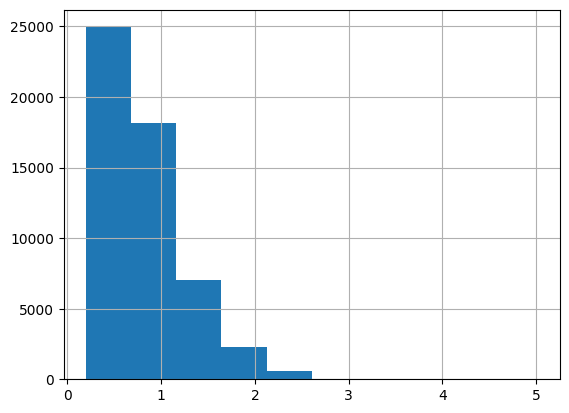

In [269]:
x_df["carat"].hist() # very skewed

<Axes: >

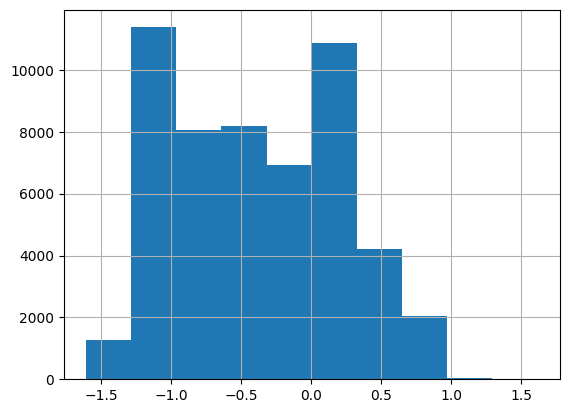

In [270]:
new_carat = np.log(x_df["carat"])
normaltest(new_carat) # normal test not working
new_carat.hist() #more normal

(array([1.0230e+03, 9.9810e+03, 6.4620e+03, 7.2110e+03, 7.0100e+03,
        1.2826e+04, 5.6860e+03, 2.6030e+03, 1.7800e+02, 9.0000e+00]),
 array([-1.75170591, -1.42814949, -1.10459308, -0.78103667, -0.45748026,
        -0.13392384,  0.18963257,  0.51318898,  0.83674539,  1.16030181,
         1.48385822]),
 <BarContainer object of 10 artists>)

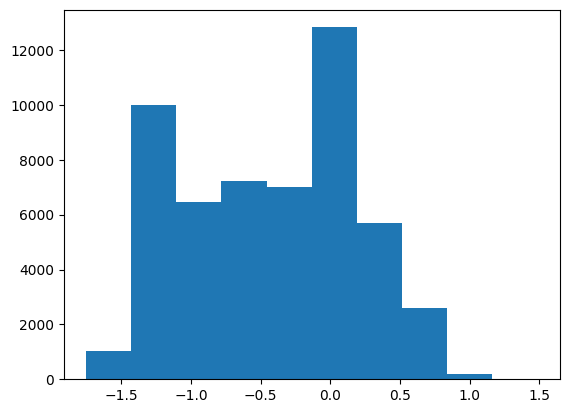

In [271]:
newCaratArr = boxcox(x_df["carat"])
newCarat = newCaratArr[0]
normaltest(newCarat) #still 0
plt.hist(newCarat) # more normal



In [272]:
x_df["carat"] = newCarat
x_df

,Unnamed: 0,carat,depth,table,cut_encoded,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2,color_E,color_F,color_G,color_H,color_I,color_J
0,1.0,-1.587720,61.5,55.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2.0,-1.694189,59.8,61.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,4.0,-1.320934,62.4,58.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5.0,-1.245359,63.3,58.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,6.0,-1.538255,62.8,57.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,53936.0,-0.334170,60.8,57.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53936,53937.0,-0.334170,63.1,55.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53937,53938.0,-0.363361,62.8,60.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53938,53939.0,-0.152010,61.0,58.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


NormaltestResult(statistic=1513.3979022151063, pvalue=0.0)

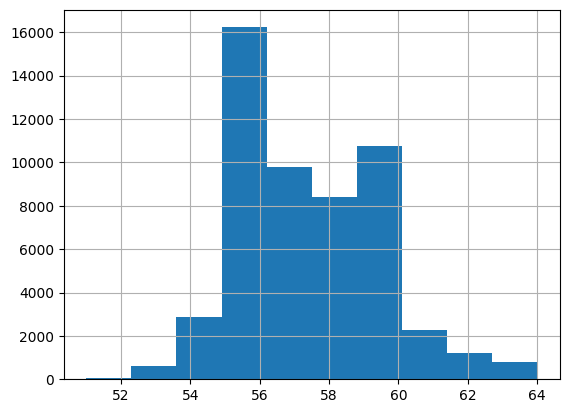

In [273]:
x_df["table"].hist() # almost normal
normaltest(x_df["table"]) # still 0

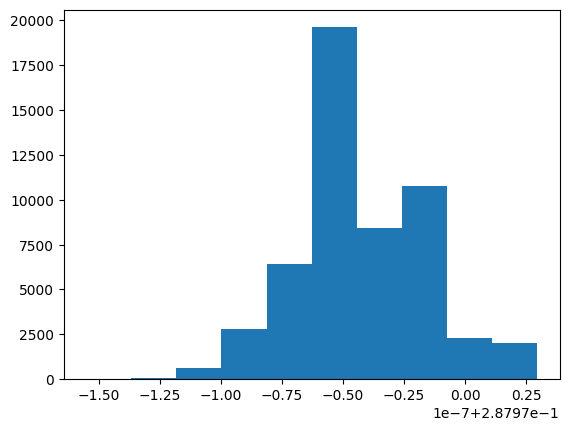

In [274]:
newTableArr = boxcox(x_df["table"])
newTable = newTableArr[0]
normaltest(newTable) #still 0
plt.hist(newTable) # more normal
x_df["table"] = newTable

<Axes: >

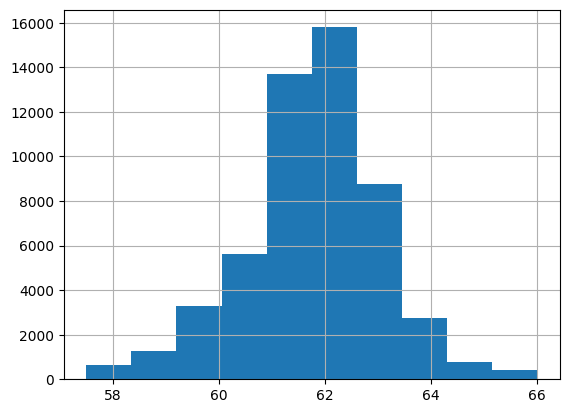

In [275]:
x_df["depth"].hist() # also almost normal

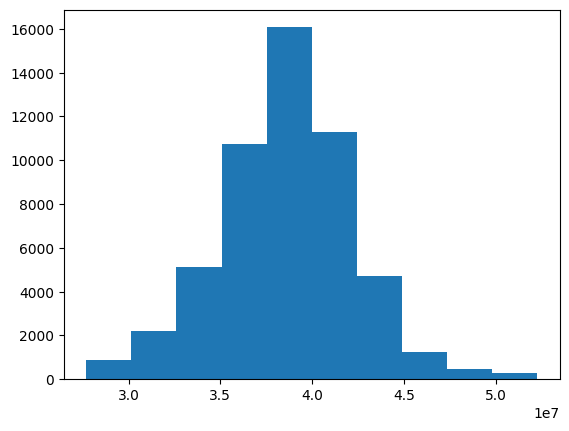

In [276]:
newDepthArr = boxcox(x_df["depth"])
newDepth = newDepthArr[0]
normaltest(newDepth) #still 0
plt.hist(newDepth) # more normal
x_df["depth"] = newDepth

array([[<Axes: title={'center': 'price'}>]], dtype=object)

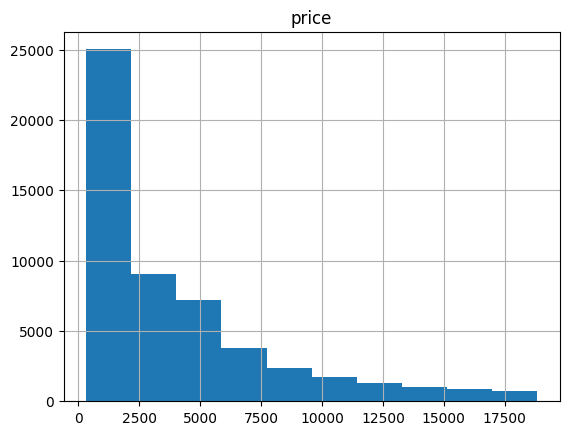

In [277]:
y_df.hist() #extremely skewed

,price
0,4.749756
1,4.749756
3,4.765849
4,4.767832
5,4.769808
...,...
53935,6.066367
53936,6.066367
53937,6.066367
53938,6.066367


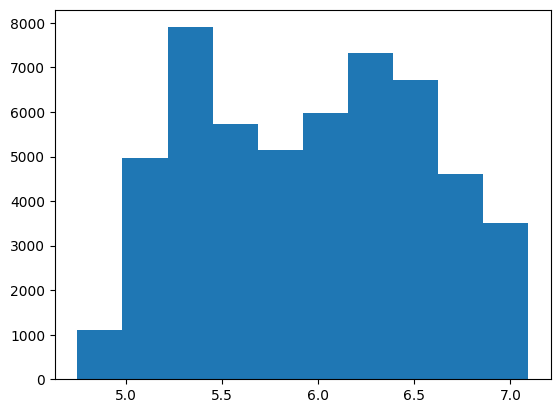

In [278]:
newPriceArr = boxcox(y_df["price"])
newPrice = newPriceArr[0]
plt.hist(newPrice) # more normal
y_df["price"] = newPrice
y_df

In [279]:
duplicateRows = x_df[x_df.duplicated()]
duplicateRows #no duplicates

,Unnamed: 0,carat,depth,table,cut_encoded,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2,color_E,color_F,color_G,color_H,color_I,color_J


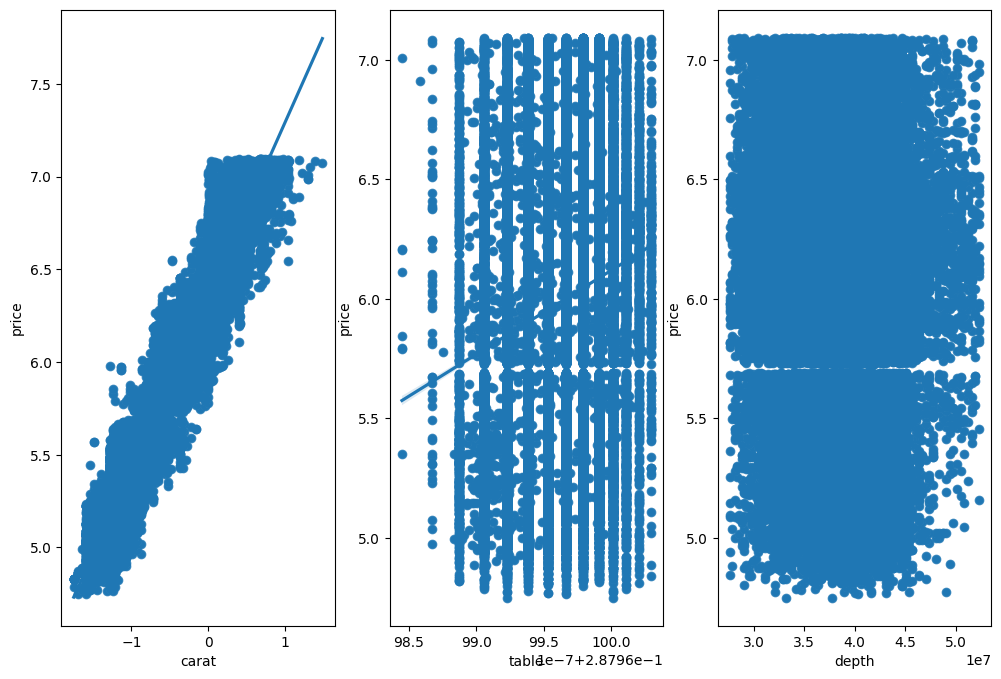

In [280]:
#Checking for linearity
fig, (ax1, ax2, ax3) = plt.subplots(figsize = (12,8), ncols=3,sharey=False)
sns.scatterplot( x = x_df["carat"], y = y_df["price"],  ax=ax1) # definetly linear
sns.regplot(x=x_df["carat"], y=y_df["price"], ax=ax1)
 
sns.scatterplot(x = x_df["table"],y = y_df["price"], ax=ax2) #not linear
sns.regplot(x=x_df["table"], y=y_df["price"], ax=ax2);

sns.scatterplot(x = x_df["depth"],y = y_df["price"], ax=ax3) #not linear at all
sns.regplot(x=x_df["depth"], y=y_df["price"], ax=ax3);


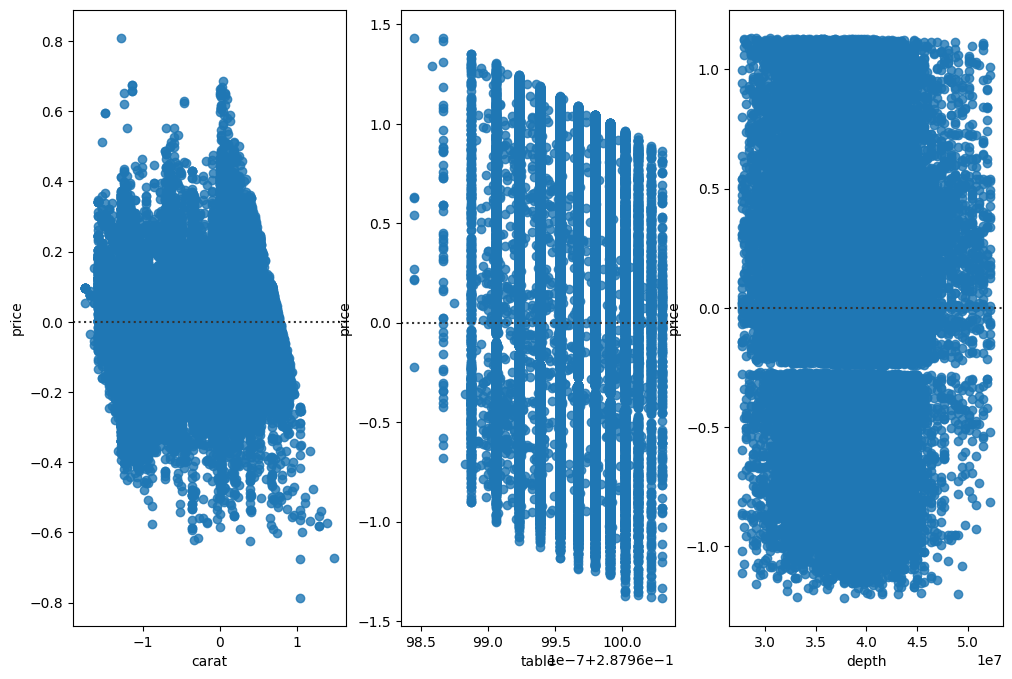

In [281]:
#Checking for linearity
fig, (ax1, ax2, ax3) = plt.subplots(figsize = (12,8), ncols=3,sharey=False)
sns.residplot(x=x_df["carat"], y=y_df["price"], ax=ax1) #good

sns.residplot(x=x_df["table"], y=y_df["price"], ax=ax2); #meh

sns.residplot(x=x_df["depth"], y=y_df["price"], ax=ax3); #good


In [282]:
#Splitting the data
X_train, X_test, y_train, y_test = train_test_split( x_df, y_df, test_size=0.30, random_state=0)

In [283]:
# Model 1: Linear Regression (no regularization)
model_no_reg = make_pipeline(StandardScaler(), LinearRegression())
model_no_reg.fit(X_train, y_train)

# Model 2: Ridge Regression (L2)
model_ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))  # alpha = regularization strength
model_ridge.fit(X_train, y_train)

# Model 3: Lasso Regression (L1)
model_lasso = make_pipeline(StandardScaler(), Lasso(alpha=1.0))
model_lasso.fit(X_train, y_train)

# Model 4: Elastic Net (L1 + L2)
model_elastic = make_pipeline(StandardScaler(), ElasticNet(alpha=0.01, l1_ratio=0.5))  # l1_ratio = 0.5 balances L1/L2
model_elastic.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('elasticnet', ElasticNet(alpha=0.01))])

In [284]:
results = []
models = {
    "No Regularization": model_no_reg,
    "Ridge (L2)": model_ridge,
    "Lasso (L1)": model_lasso,
    "Elastic Net (L1+L2)": model_elastic,
}

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    train_r2 = r2_score(y_train, y_train_pred)
    y_test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_r2_adj = (1 - (1 - train_r2) * ((X_train.shape[0] - 1) / 
          (X_train.shape[0] - X_train.shape[1] - 1)))
    test_r2_adj = (1 - (1 - test_r2) * ((X_test.shape[0] - 1) / 
          (X_test.shape[0] - X_test.shape[1] - 1)))  
    results.append({
        "Model": name,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²":  test_r2,
        "Train Adj R²": train_r2_adj,
        "Test Adj R²": test_r2_adj
    })

df_results = pd.DataFrame(results)
df_results

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R²,Test R²,Train Adj R²,Test Adj R²
0,No Regularization,0.005818,0.005951,0.076276,0.077140,0.983034,9.826758e-01,0.983026,0.982656
1,Ridge (L2),0.005818,0.005951,0.076276,0.077141,0.983034,9.826754e-01,0.983026,0.982656
2,Lasso (L1),0.342925,0.343487,0.585598,0.586077,0.000000,-4.948220e-07,-0.000486,-0.001134
3,Elastic Net (L1+L2),0.008082,0.008478,0.089898,0.092077,0.976433,9.753174e-01,0.976421,0.975289


Text(0, 0.5, 'Predicted')

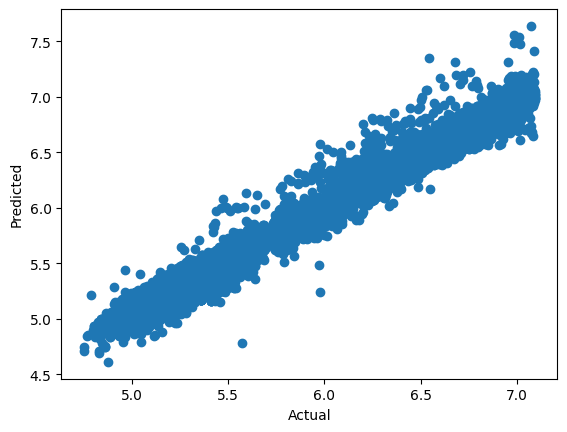

In [285]:
#Plotting predicted vs actual prices(after boxcox)
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [286]:
#Plotting coefficients in models
coefs = {
    "No Regularization": model_no_reg.named_steps['linearregression'].coef_.ravel(),
    "Ridge (L2)": model_ridge.named_steps['ridge'].coef_.ravel(),
    "Lasso (L1)": model_lasso.named_steps['lasso'].coef_.ravel(),
    "Elastic Net (L1+L2)": model_elastic.named_steps['elasticnet'].coef_.ravel(),
}

df_coefs = pd.DataFrame(coefs, index=[f"Feature {i+1}" for i in range(x_df.shape[1])])
df_coefs

,No Regularization,Ridge (L2),Lasso (L1),Elastic Net (L1+L2)
Feature 1,-0.009184,-0.009191,-0.0,-0.005791
Feature 2,0.630282,0.630246,0.0,0.606440
Feature 3,-0.000900,-0.000903,0.0,-0.000000
Feature 4,0.001281,0.001281,0.0,0.000000
Feature 5,0.016942,0.016945,-0.0,0.014129
Feature 6,0.111810,0.111656,-0.0,0.039130
Feature 7,0.135164,0.134816,0.0,-0.009634
Feature 8,0.084226,0.083926,0.0,-0.037948
Feature 9,0.157799,0.157503,-0.0,0.024771
Feature 10,0.169328,0.168982,-0.0,0.017015


<Axes: >

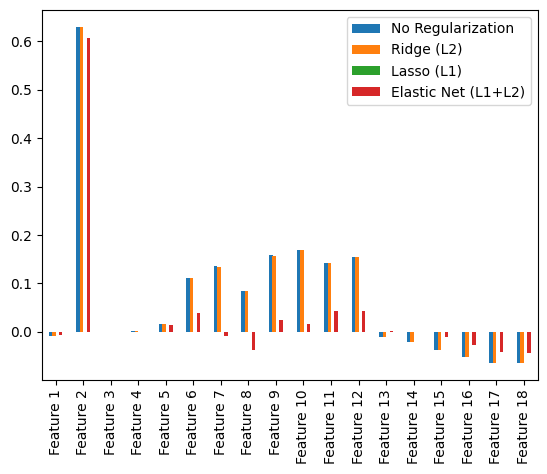

In [287]:
df_coefs.plot(kind='bar')

<Figure size 1400x600 with 0 Axes>

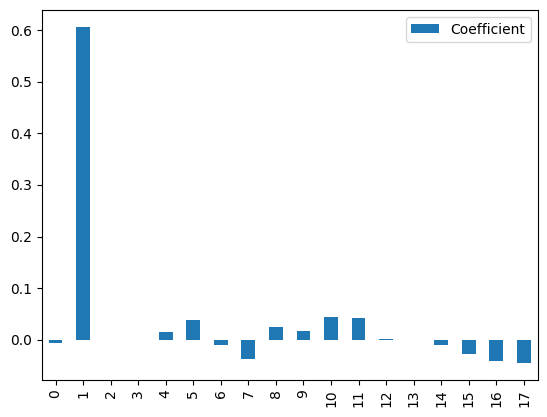

In [288]:
#Plotting elastic zero coeffs (I definetly messed up here), #while lasso was all zeroes
model_elastic = model_elastic.named_steps['elasticnet']
elastic_coefs = model_elastic.coef_.ravel()
feature_names = x_df.columns
zero_coef_features = x_df.columns[elastic_coefs == 0]
elastic_df = pd.DataFrame({
    'Feature': x_df.columns,
    'Coefficient': elastic_coefs
})

plt.figure(figsize=(14, 6))
elastic_df.plot(kind='bar')
plt.show()

In [289]:
#Summary: Linear regression and ridge were the best as they had 98% accuracy and mse,rmse closest to 0
# while lasso was the worst(probably because its coefficients shrinked the coefficients all the way to 0)